# <center> Pipelines и сериализация моделей </center>

In [1]:
import pandas as pd
import numpy as np

# Пара библиотек для визуализации
import matplotlib.pyplot as plt
%matplotlib inline


# from IPython.core.display import display, HTML
# display(HTML("<style>.container { width:80% !important; }</style>"))

import warnings
warnings.filterwarnings("ignore")

# Импорт Данных

In [2]:
# file_path = 'https://raw.githubusercontent.com/a-milenkin/Datasetes_for_Piplines/main/responses.csv'
file_path = './responses.csv'
data = pd.read_csv(file_path)

In [3]:
data.shape

(1010, 150)



## Про датасет


    
Результаты опроса молодежи до 21-го года по тому, какие вещи делют их счастливыми по 5-й шкале
    
</div>


In [4]:

data.head()

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
0,5.0,3.0,2.0,1.0,2.0,2.0,1.0,5.0,5.0,1.0,...,20.0,163.0,48.0,1.0,female,right handed,college/bachelor degree,no,village,block of flats
1,4.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,5.0,4.0,...,19.0,163.0,58.0,2.0,female,right handed,college/bachelor degree,no,city,block of flats
2,5.0,5.0,2.0,2.0,3.0,4.0,5.0,3.0,5.0,3.0,...,20.0,176.0,67.0,2.0,female,right handed,secondary school,no,city,block of flats
3,5.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,22.0,172.0,59.0,1.0,female,right handed,college/bachelor degree,yes,city,house/bungalow
4,5.0,3.0,4.0,3.0,2.0,4.0,3.0,5.0,3.0,1.0,...,20.0,170.0,59.0,1.0,female,right handed,secondary school,no,village,house/bungalow


In [5]:
print(list(data.columns))

['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 'Techno, Trance', 'Opera', 'Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 'Documentary', 'Western', 'Action', 'History', 'Psychology', 'Politics', 'Mathematics', 'Physics', 'Internet', 'PC', 'Economy Management', 'Biology', 'Chemistry', 'Reading', 'Geography', 'Foreign languages', 'Medicine', 'Law', 'Cars', 'Art exhibitions', 'Religion', 'Countryside, outdoors', 'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 'Active sport', 'Gardening', 'Celebrities', 'Shopping', 'Science and technology', 'Theatre', 'Fun with friends', 'Adrenaline sports', 'Pets', 'Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 'Rats', 'Ageing', 'Dangerous dogs', 'Fear of public speaking', 'Smoking', 'Alcohol',

## Про Задачу

Попробуем классифицировать людей по оценкам уровня счастья
    



In [3]:
interesting_features = ["Happiness in life", "Age", "Height", "Gender", "Weight",
              "Left - right handed", "Village - town", "Getting up", "God",
              "Health", "Borrowed stuff", "Self-criticism", "Elections",
              "Smoking", "Alcohol" ,"Number of friends", "Spending on healthy eating",
              "Music", "Movies", "Friends versus money", "Changing the past"]


target = ["Happiness in life"]

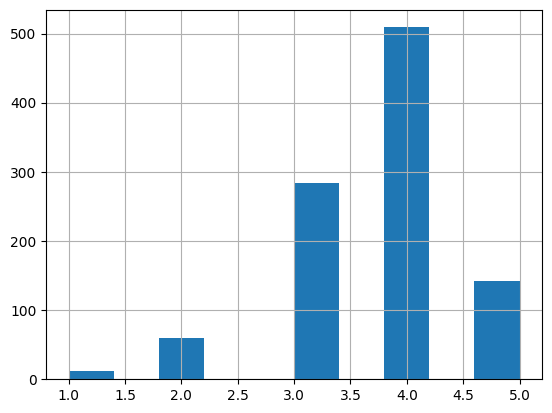

In [7]:
data["Happiness in life"].hist();

In [4]:
data = data[interesting_features]

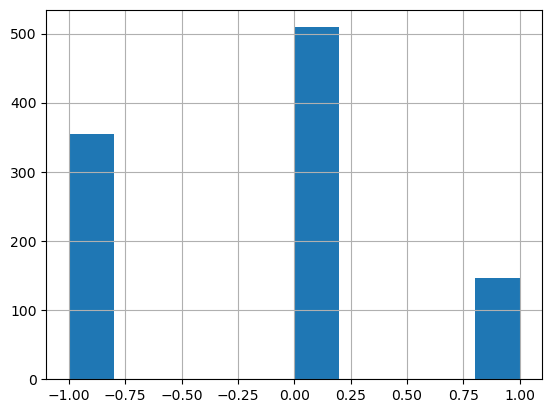

In [5]:
# Сбалансируем немного классы

def happiness_score(x):
    if x < 4:
        return -1
    elif x == 4.0:
        return 0
    else:
        return 1

data["Happiness in life"] = data["Happiness in life"].apply(happiness_score)

data["Happiness in life"].hist();

# Как пишут код обычно? - The painful way

In [10]:
data["Happiness in life"].unique()

array([ 0, -1,  1])

## Проведем EDA

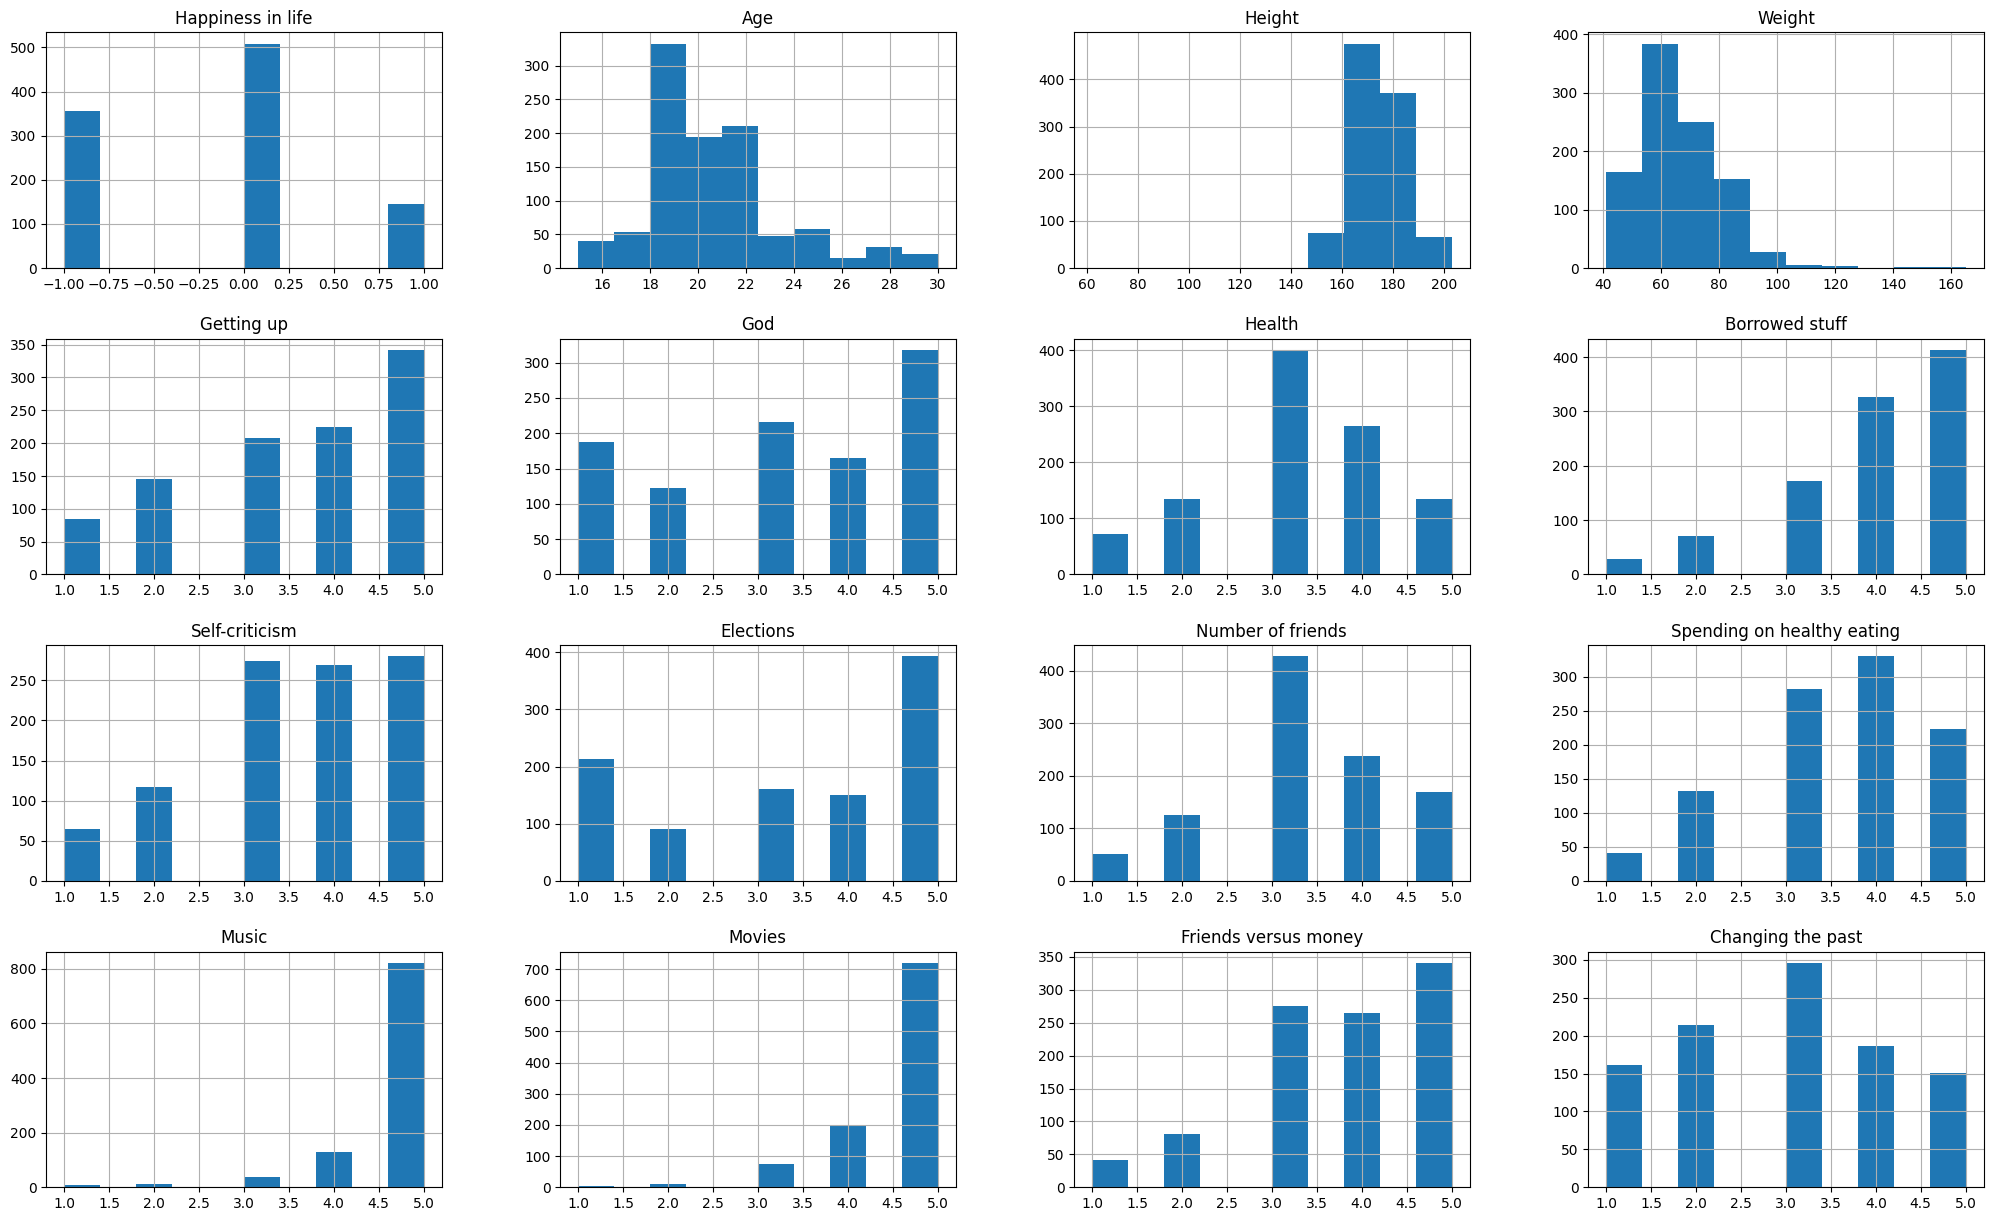

In [11]:
data.hist(figsize=(25, 15))

plt.show()

# Есть ли в данных пропуски? Есть почти всегда!

In [12]:
data.isnull().sum().head()

,0
Happiness in life,0
Age,7
Height,20
Gender,6
Weight,20


Разбиваем на трейн и тест.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

data_cleaned = data.dropna()
data_train, data_test = train_test_split(data_cleaned, test_size=0.2, stratify=data_cleaned[target], random_state = 42)

print(data_train.shape, data_test.shape)

(740, 21) (185, 21)


In [14]:
data_train.head()

,Happiness in life,Age,Height,Gender,Weight,Left - right handed,Village - town,Getting up,God,Health,...,Self-criticism,Elections,Smoking,Alcohol,Number of friends,Spending on healthy eating,Music,Movies,Friends versus money,Changing the past
553,-1,18.0,170.0,female,53.0,right handed,village,3.0,5.0,4.0,...,5.0,1.0,never smoked,social drinker,3,2.0,3.0,4.0,4.0,5.0
987,-1,20.0,184.0,male,80.0,right handed,city,5.0,2.0,2.0,...,5.0,5.0,current smoker,drink a lot,2,2.0,4.0,4.0,4.0,4.0
861,0,18.0,172.0,female,55.0,right handed,city,5.0,2.0,4.0,...,2.0,3.0,tried smoking,drink a lot,4,4.0,5.0,5.0,4.0,2.0
204,0,24.0,169.0,female,51.0,right handed,city,5.0,1.0,3.0,...,5.0,3.0,never smoked,drink a lot,3,2.0,5.0,5.0,2.0,1.0
47,0,19.0,170.0,female,60.0,right handed,city,3.0,2.0,5.0,...,3.0,2.0,tried smoking,social drinker,4,3.0,5.0,5.0,5.0,2.0


In [15]:
data['Smoking'].value_counts()

,count
Smoking,
tried smoking,430
never smoked,208
current smoker,189
former smoker,175


# Какие признаки в данных?

In [7]:
numerical_features = ['Age', 'Height', 'Weight', "Number of friends"]  # Числовые переменные

# Бинарные признаки
to_dummies = [
    'Gender', 'Left - right handed', 'Village - town',
]

# Категориальные признаки
categorical_features = [
    col for col in data.columns if col not in numerical_features + target + to_dummies
]

all_features = categorical_features + numerical_features
len(all_features)

17

In [17]:
data[numerical_features].head()

,Age,Height,Weight,Number of friends
0,20.0,163.0,48.0,3
1,19.0,163.0,58.0,3
2,20.0,176.0,67.0,3
3,22.0,172.0,59.0,1
4,20.0,170.0,59.0,3


In [8]:
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder, MinMaxScaler

In [19]:
help(LabelEncoder)

Help on class LabelEncoder in module sklearn.preprocessing._label:

class LabelEncoder(sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  Encode target labels with value between 0 and n_classes-1.
 |
 |  This transformer should be used to encode target values, *i.e.* `y`, and
 |  not the input `X`.
 |
 |  Read more in the :ref:`User Guide <preprocessing_targets>`.
 |
 |  .. versionadded:: 0.12
 |
 |  Attributes
 |  ----------
 |  classes_ : ndarray of shape (n_classes,)
 |      Holds the label for each class.
 |
 |  See Also
 |  --------
 |  OrdinalEncoder : Encode categorical features using an ordinal encoding
 |      scheme.
 |  OneHotEncoder : Encode categorical features as a one-hot numeric array.
 |
 |  Examples
 |  --------
 |  `LabelEncoder` can be used to normalize labels.
 |
 |  >>> from sklearn.preprocessing import LabelEncoder
 |  >>> le = LabelEncoder()
 |  >>> le.fit([1, 2, 2, 6])
 |  LabelEncoder()
 |  >>> le.classes_
 |  array([1, 2, 6])
 |  >>> le.transform(

In [9]:
scaler = StandardScaler() # Нормировка для числовых признаков

In [10]:
data_train_scaled = scaler.fit_transform(data_train[numerical_features])
data_test_scaled = scaler.transform(data_test[numerical_features])
data_train_scaled[:10]

array([[-0.87607044, -0.32708138, -0.97171023, -0.31681793],
       [-0.13895603,  1.02671931,  1.00918666, -1.2776592 ],
       [-0.87607044, -0.13368128, -0.82497713,  0.64402334],
       [ 1.33527279, -0.42378143, -1.11844334, -0.31681793],
       [-0.50751323, -0.32708138, -0.45814437,  0.64402334],
       [-0.87607044,  0.44651901,  0.27552114, -1.2776592 ],
       [-0.13895603,  0.15641886, -0.97171023,  1.60486461],
       [-1.24462764, -0.81058163, -0.60487747,  0.64402334],
       [-0.50751323, -0.52048148, -0.45814437,  1.60486461],
       [-0.50751323,  0.63991911,  1.00918666, -0.31681793]])

In [11]:
ohe = OneHotEncoder(sparse_output=False)

data_train_ohe = ohe.fit_transform(data_train[to_dummies])
data_test_ohe = ohe.transform(data_test[to_dummies])
data_train_ohe[:10]

array([[1., 0., 0., 1., 0., 1.],
       [0., 1., 0., 1., 1., 0.],
       [1., 0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 1., 0.],
       [0., 1., 0., 1., 1., 0.],
       [1., 0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0., 1.],
       [0., 1., 1., 0., 0., 1.]])

In [12]:
data_train_transformed = pd.concat([pd.DataFrame(data_train_scaled, columns=numerical_features),
                                    pd.DataFrame(data_train_ohe, columns=ohe.get_feature_names_out()),
                                   # pd.DataFrame(data_train[categorical_features].values)
                                   ], axis=1)
data_test_transformed = pd.concat([pd.DataFrame(data_test_scaled, columns=numerical_features),
                                    pd.DataFrame(data_test_ohe, columns=ohe.get_feature_names_out()),
                                   # pd.DataFrame(data_train[categorical_features].values)
                                   ], axis=1)
data_train_transformed.head()

,Age,Height,Weight,Number of friends,Gender_female,Gender_male,Left - right handed_left handed,Left - right handed_right handed,Village - town_city,Village - town_village
0,-0.876070,-0.327081,-0.971710,-0.316818,1.0,0.0,0.0,1.0,0.0,1.0
1,-0.138956,1.026719,1.009187,-1.277659,0.0,1.0,0.0,1.0,1.0,0.0
2,-0.876070,-0.133681,-0.824977,0.644023,1.0,0.0,0.0,1.0,1.0,0.0
3,1.335273,-0.423781,-1.118443,-0.316818,1.0,0.0,0.0,1.0,1.0,0.0
4,-0.507513,-0.327081,-0.458144,0.644023,1.0,0.0,0.0,1.0,1.0,0.0


# ML часть

In [13]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer

In [14]:
model = LogisticRegression()

model.fit(data_train_transformed, data_train[target])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
data_test[target[0]].unique()

array([ 0, -1,  1])

In [15]:
preds = model.predict(data_test_transformed)


print(classification_report(data_test[target], preds))

              precision    recall  f1-score   support

          -1       0.64      0.28      0.39        65
           0       0.54      0.91      0.68        93
           1       0.00      0.00      0.00        27

    accuracy                           0.56       185
   macro avg       0.39      0.40      0.36       185
weighted avg       0.50      0.56      0.48       185



## Что не так с этим способом?

<div class="alert alert-warning">


 - Дублируем код ли кода

 - Сложно маcштабировать

 - Сложно поддерживать свой код
    
 - Много времени тратится на написание(

# Как пишут код true-датасаентисты - The pipeline way

<div>
<img src="https://i.pinimg.com/564x/41/d2/4b/41d24b25710d7746b22a7eb34316952c.jpg" width="500"/>
</div>

<div class="alert alert-info">

`Pipeline` позволяет обернуть сразу несколько этапов обработки данных в один объект

- **FunctionTransformer**: преобразует функцию в трансформер
- **FeatureUnion**: объединяет результаты нескольких трансформеров в один датасет
- **ColumnTransformer**: выбирает определенные колонки
- **make_pipeline**: удобная обертка для создания пайплайна, можно использовать вместо Pipeline

In [23]:
# Гости этого вечера. Нужные нам фрагменты для сборки пайплайна

from sklearn.pipeline import Pipeline, make_pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.impute import SimpleImputer #, KNNImputer
from sklearn.feature_selection import SelectKBest, chi2, f_classif

In [28]:
help(SimpleImputer)

Help on class SimpleImputer in module sklearn.impute._base:

class SimpleImputer(_BaseImputer)
 |  SimpleImputer(*, missing_values=nan, strategy='mean', fill_value=None, copy=True, add_indicator=False, keep_empty_features=False)
 |
 |  Univariate imputer for completing missing values with simple strategies.
 |
 |  Replace missing values using a descriptive statistic (e.g. mean, median, or
 |  most frequent) along each column, or using a constant value.
 |
 |  Read more in the :ref:`User Guide <impute>`.
 |
 |  .. versionadded:: 0.20
 |     `SimpleImputer` replaces the previous `sklearn.preprocessing.Imputer`
 |     estimator which is now removed.
 |
 |  Parameters
 |  ----------
 |  missing_values : int, float, str, np.nan, None or pandas.NA, default=np.nan
 |      The placeholder for the missing values. All occurrences of
 |      `missing_values` will be imputed. For pandas' dataframes with
 |      nullable integer dtypes with missing values, `missing_values`
 |      can be set to eit

In [24]:
#   Для категориальных - применяем SimpleImputer, а затем StandardScaler
numerical_transformer = Pipeline(steps=[ ("imputer", SimpleImputer()),
                                        ("scaler", StandardScaler()),
                                        ("fs", SelectKBest(score_func=f_classif, k="all")), ])

#   Для категориальных - применяем SimpleImputer, а затем OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot", OneHotEncoder(sparse_output=False))])


# Собираем воедино трансформеры для числовых и категориальных признаков
data_transformer = ColumnTransformer(transformers=[
    ("numerical", numerical_transformer, numerical_features), # make_column_selector
    ("categorical", categorical_transformer, categorical_features),
])

# Создание конвейера препроцессора, который сначала преобразует данные
preprocessor = Pipeline(steps=[("data_transformer", data_transformer)])

classifier_pipline = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("classifier",  LogisticRegression())])


# Добавим магии - отрисовка!

In [25]:
import sklearn
sklearn.set_config(display='diagram') #Подключим визуал

In [31]:
classifier_pipline

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('data_transformer',
                                  ColumnTransformer(transformers=[('numerical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer()),
                                                                                   ('scaler',
                                                                                    StandardScaler()),
                                                                                   ('fs',
                                                                                    SelectKBest(k='all'))]),
                                                                   ['Age',
                                                                    'Height',
                                                                    'Weight',
                                                                    'Number of '
                                                                    'friends']),
                                                                  ('categorical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(sparse_output=False))]),
                                                                   ['Getting '
                                                                    'up',
                                                                    'God',
                                                                    'Health',
                                                                    'Borrowed '
                                                                    'stuff',
                                                                    'Self-criticism',
                                                                    'Elections',
                                                                    'Smoking',
                                                                    'Alcohol',
                                                                    'Spending '
                                                                    'on '
                                                                    'healthy '
                                                                    'eating',
                                                                    'Music',
                                                                    'Movies',
                                                                    'Friends '
                                                                    'versus '
                                                                    'money',
                                                                    'Changing '
                                                                    'the '
                                                                    'past'])]))])),
                ('classifier', LogisticRegression())])

In [26]:
from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(data[all_features + target], test_size=0.2, stratify=data[target], random_state = 42)
print(data_train.shape, data_test.shape)

(808, 18) (202, 18)


In [27]:
classifier_pipline.fit(data_train, data_train[target])

preds = classifier_pipline.predict(data_test)

print(classification_report(data_test[target], preds))

              precision    recall  f1-score   support

          -1       0.46      0.38      0.42        71
           0       0.56      0.64      0.60       102
           1       0.48      0.45      0.46        29

    accuracy                           0.52       202
   macro avg       0.50      0.49      0.49       202
weighted avg       0.51      0.52      0.51       202



# А как подбирать параметры у этой всей махины??

In [28]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer
f1 = make_scorer(f1_score, average="macro")

In [29]:
param_grid = {
    'classifier__C': np.logspace(-5, 2, 10), # np.linspace(-10, 10)
    'classifier__penalty': ['l1', 'l2'],
    'preprocessor__data_transformer__numerical__imputer__strategy':['median', 'mean']
}

search = GridSearchCV(classifier_pipline, param_grid,
                      verbose=True,
                      n_jobs=-1, cv=3, scoring=f1)

search.fit(data_train.drop(target, axis=1), data_train[target])

Fitting 3 folds for each of 40 candidates, totalling 120 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'classifier__C': array([1.0000...00000000e+02]), 'classifier__penalty': ['l1', 'l2'], 'preprocessor__data_tra...ical__imputer__strategy': ['median', 'mean']}"
,scoring,make_scorer(f...average=macro)
,n_jobs,-1
,refit,True
,cv,3
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('data_transformer', ...)]"


<div class="alert alert-info">

Нам даже не нужно теперь делить на `train` и `test`, ведь есть валидация

In [36]:
search.best_params_

{'classifier__C': np.float64(0.4641588833612782),
 'classifier__penalty': 'l2',
 'preprocessor__data_transformer__numerical__imputer__strategy': 'mean'}

In [37]:
search.best_score_

np.float64(0.5142944874012901)

# Еще раз, но по шагам!

In [38]:
classifier_pipline = Pipeline( # make_pipline
    steps=[('preprocessor', preprocessor),
           ('classifier', LogisticRegression())])

# make_pipline(preprocessor, LogisticRegression())

In [39]:
# Создание конвейера препроцессора, который сначала преобразует данные.
preprocessor = Pipeline(steps=[("data_transformer", data_transformer)])


# Собираем воедино трансформеры для числовых и категориальных признаков
data_transformer = ColumnTransformer(
    transformers=[
        ("numerical", numerical_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features),
       # ("time_series", time_transformer, categorical_features),
    ]
)

In [40]:
#   Для категориальных - применяем SimpleImputer, а затем StandardScaler

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer()),
        ("scaler", StandardScaler()),
        ("fs", SelectKBest(score_func=f_classif, k="all")),
    ]
)

In [41]:
#   Для категориальных - применяем SimpleImputer, а затем OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot", OneHotEncoder(sparse_output=False))])



classifier_pipline

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('data_transformer',
                                  ColumnTransformer(transformers=[('numerical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer()),
                                                                                   ('scaler',
                                                                                    StandardScaler()),
                                                                                   ('fs',
                                                                                    SelectKBest(k='all'))]),
                                                                   ['Age',
                                                                    'Height',
                                                                    'Weight',
                                                                    'Number of '
                                                                    'friends']),
                                                                  ('categorical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(sparse_output=False))]),
                                                                   ['Getting '
                                                                    'up',
                                                                    'God',
                                                                    'Health',
                                                                    'Borrowed '
                                                                    'stuff',
                                                                    'Self-criticism',
                                                                    'Elections',
                                                                    'Smoking',
                                                                    'Alcohol',
                                                                    'Spending '
                                                                    'on '
                                                                    'healthy '
                                                                    'eating',
                                                                    'Music',
                                                                    'Movies',
                                                                    'Friends '
                                                                    'versus '
                                                                    'money',
                                                                    'Changing '
                                                                    'the '
                                                                    'past'])]))])),
                ('classifier', LogisticRegression())])

# А если вдруг одной модели мало?

In [30]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
help(VotingClassifier)

Help on class VotingClassifier in module sklearn.ensemble._voting:

class VotingClassifier(sklearn.base.ClassifierMixin, _BaseVoting)
 |  VotingClassifier(estimators, *, voting='hard', weights=None, n_jobs=None, flatten_transform=True, verbose=False)
 |
 |  Soft Voting/Majority Rule classifier for unfitted estimators.
 |
 |  Read more in the :ref:`User Guide <voting_classifier>`.
 |
 |  .. versionadded:: 0.17
 |
 |  Parameters
 |  ----------
 |  estimators : list of (str, estimator) tuples
 |      Invoking the ``fit`` method on the ``VotingClassifier`` will fit clones
 |      of those original estimators that will be stored in the class attribute
 |      ``self.estimators_``. An estimator can be set to ``'drop'`` using
 |      :meth:`set_params`.
 |
 |      .. versionchanged:: 0.21
 |          ``'drop'`` is accepted. Using None was deprecated in 0.22 and
 |          support was removed in 0.24.
 |
 |  voting : {'hard', 'soft'}, default='hard'
 |      If 'hard', uses predicted class lab

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost

clf1 = LogisticRegression(multi_class="multinomial", random_state=7575)
clf2 = RandomForestClassifier(n_estimators=50, random_state = 7575)
clf3 = KNeighborsClassifier(5)

blending_classifier = VotingClassifier(
    estimators=[("log_regrassion", clf1),
                ("random_forest", clf2),
                ("knn", clf3)]
)
blending_classifier

,estimators,"[('log_regrassion', ...), ('random_forest', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [32]:
classifier_pipline = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("classifier", blending_classifier)]
)

classifier_pipline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('data_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [33]:
classifier_pipline.fit(data_train, data_train[target])

preds = classifier_pipline.predict(data_test)

print(classification_report(data_test[target], preds))

              precision    recall  f1-score   support

          -1       0.39      0.37      0.38        71
           0       0.53      0.66      0.59       102
           1       0.90      0.31      0.46        29

    accuracy                           0.50       202
   macro avg       0.61      0.44      0.48       202
weighted avg       0.54      0.50      0.50       202



# А что если хотим использовать стекинг?

In [34]:
# Your code here.
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier

In [46]:
# получим список эстиматоров
estimators = [
    ("Random_Forest", RandomForestClassifier()),
    ("Xgboost", xgboost.XGBClassifier()),
    ("SVM", LinearSVC()),

]

# построим классификатор используя стекинг и наш список классификаторов
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(n_jobs=-1, verbose=True),
    n_jobs=-1,
    verbose=True,
)

In [47]:
stacking_classifier

StackingClassifier(estimators=[('Random_Forest', RandomForestClassifier()),
                               ('Xgboost',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_pol...
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('SVM', LinearSVC())],
                   final_estimator=LogisticRegression(n_jobs=-1, verbose=True),
                   n_jobs=-1, verbose=True)

In [35]:
# получим список эстиматоров
estimators = [
    ("Random_Forest", RandomForestClassifier()),
    ("SVM", LinearSVC()),
    ("Xgboost", xgboost.XGBClassifier()),
]

# построим классификатор используя стекинг и наш список классификаторов
stacking_classifier = StackingClassifier(
    estimators=estimators, final_estimator=LogisticRegression(n_jobs=-1), n_jobs=-1
)

classifier_pipline = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("classifier", stacking_classifier)]
)

classifier_pipline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('data_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


# Чуть более хитрый стекинг/блендинг моделей

In [36]:
from sklearn.decomposition import PCA

# получим список эстиматоров
estimators = [
    ("SVM", make_pipeline(preprocessor, PCA(), LinearSVC())),
    ("Random_Forest", make_pipeline(preprocessor, RandomForestClassifier())),
    ("Xgboost", make_pipeline(preprocessor, xgboost.XGBClassifier())),
]

# построим классификатор используя стекинг и наш список классификаторов
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(n_jobs=-1, verbose=True),
    n_jobs=-1,
    verbose=True,
)

stacking_classifier

,estimators,"[('SVM', ...), ('Random_Forest', ...), ...]"
,final_estimator,LogisticRegre... verbose=True)
,cv,None
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,True
,steps,"[('data_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False


# А сколько всего кода было написано?

In [37]:
numerical_features

['Age', 'Height', 'Weight', 'Number of friends']

In [38]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("feature_selector", SelectKBest(score_func=f_classif, k="all"))])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot", OneHotEncoder(sparse_output=False))])


data_transformer = ColumnTransformer(transformers=[
    ("numerical", numerical_transformer, numerical_features),
    ("categorical", categorical_transformer, categorical_features)])

preprocessor = Pipeline(steps=[("data_transformer", data_transformer)])

estimators = [
    ("SVM", make_pipeline(preprocessor, PCA(), LinearSVC())),
    ("Random_Forest", make_pipeline(preprocessor, RandomForestClassifier(n_jobs=-1))),
    ("xgboost", make_pipeline(preprocessor, xgboost.XGBClassifier(n_jobs=-1)))]

stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(n_jobs=-1, verbose=True),
    n_jobs=-1,
    verbose=True,
)

In [39]:
stacking_classifier

,estimators,"[('SVM', ...), ('Random_Forest', ...), ...]"
,final_estimator,LogisticRegre... verbose=True)
,cv,None
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,True
,steps,"[('data_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False


# Обучении махины - Будет ли легко?

In [40]:
stacking_classifier.fit(data_train, data_train[target])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


,estimators,"[('SVM', ...), ('Random_Forest', ...), ...]"
,final_estimator,LogisticRegre... verbose=True)
,cv,None
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,True
,steps,"[('data_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False


In [41]:
preds = stacking_classifier.predict(data_test)

print(classification_report(data_test[target], preds))

              precision    recall  f1-score   support

          -1       0.49      0.32      0.39        71
           0       0.55      0.76      0.64       102
           1       0.71      0.34      0.47        29

    accuracy                           0.55       202
   macro avg       0.59      0.48      0.50       202
weighted avg       0.55      0.55      0.53       202



# Как сохранить всю эту махину?

In [55]:
# Для сериализации моделей
import pickle

In [56]:
pickle.dump(stacking_classifier, open("awesome_pipeline.pkl", "wb"))

In [57]:
with open("awesome_pipeline.pkl", "wb") as f:
    pickle.dump(stacking_classifier, f)

# Импорт модели

In [58]:
with open("awesome_pipeline.pkl", 'rb') as f:
  pipeline_from_saved = pickle.load(f)

In [59]:
pipeline_from_saved = pickle.load(open("awesome_pipeline.pkl", 'rb'))

In [60]:
preds = pipeline_from_saved.predict(data_test)
print(classification_report(data_test[target], preds))

              precision    recall  f1-score   support

          -1       0.49      0.32      0.39        71
           0       0.56      0.76      0.64       102
           1       0.67      0.34      0.45        29

    accuracy                           0.55       202
   macro avg       0.57      0.48      0.50       202
weighted avg       0.55      0.55      0.53       202



# Что дальше?

<div class="alert alert-success">
    
* Признаки бывают разные
* Предобработка бывает сложнее
* Генерация новых признаков